## Random Forest

sklearn random forest classifier documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

sklearn random forest regressor documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html 

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Import the data

In [35]:
data = pd.read_csv("./Churn_Modelling.csv")

data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [36]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [37]:
data.shape

(10000, 11)

In [38]:
# Feature and target

X = data.drop('Exited', axis=1)
y = data['Exited'].values.flatten()

In [39]:
# Distribution of the classes in the target variable

unique, counts = np.unique(y, return_counts=True)

# Create a dictionary for easy reading
distribution = dict(zip(unique.tolist(), counts.tolist()))
print(distribution)

{0: 7963, 1: 2037}


In [40]:
# splitting the data into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=123)

X_train.shape, X_test.shape

((7500, 10), (2500, 10))

### Encoding the variables

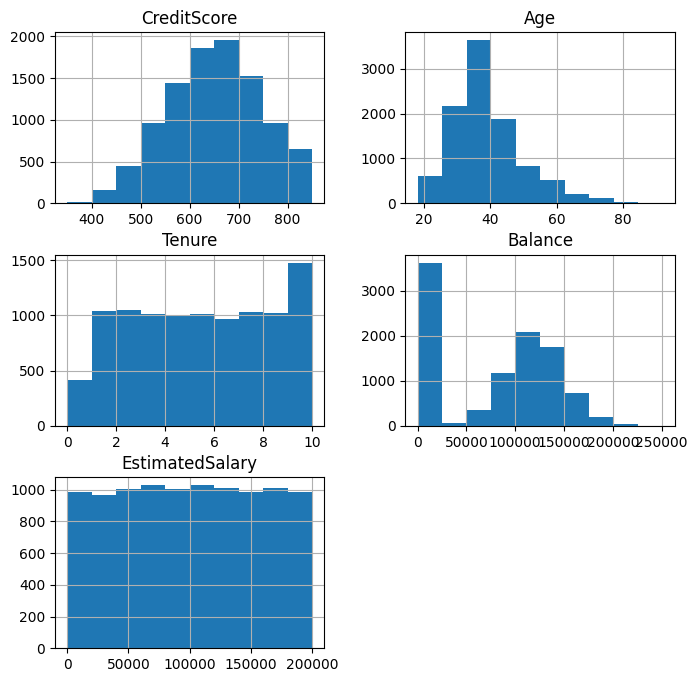

In [41]:
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
categorical_cols_non_enc = ['Geography', 'Gender']
categorical_cols_enc = ['NumOfProducts','HasCrCard', 'IsActiveMember']

X[numerical_cols].hist(figsize=(8,8));

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [43]:
preprocessor = ColumnTransformer(
                    transformers=[
                        ("standard_scaler", StandardScaler(), numerical_cols),
                        ("one_hot_encoder", OneHotEncoder(), categorical_cols_non_enc),
                        ("categorical_passthrough", "passthrough", categorical_cols_enc)
                    ]
                )

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [44]:
X_train.shape

(7500, 13)

In [45]:
preprocessor.get_feature_names_out()

array(['standard_scaler__CreditScore', 'standard_scaler__Age',
       'standard_scaler__Tenure', 'standard_scaler__Balance',
       'standard_scaler__EstimatedSalary',
       'one_hot_encoder__Geography_France',
       'one_hot_encoder__Geography_Germany',
       'one_hot_encoder__Geography_Spain',
       'one_hot_encoder__Gender_Female', 'one_hot_encoder__Gender_Male',
       'categorical_passthrough__NumOfProducts',
       'categorical_passthrough__HasCrCard',
       'categorical_passthrough__IsActiveMember'], dtype=object)

In [46]:
output_features = [x.split("__")[-1] for x in preprocessor.get_feature_names_out()]

output_features

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'EstimatedSalary',
 'Geography_France',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Female',
 'Gender_Male',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember']

### Fitting the random forest model

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
# define the classifier
clf = RandomForestClassifier(n_estimators=200, min_samples_split=10)

# train the classifier
clf.fit(X_train, y_train)

clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

### Evaluating on test data

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Evaluating the model on train dataset
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8720


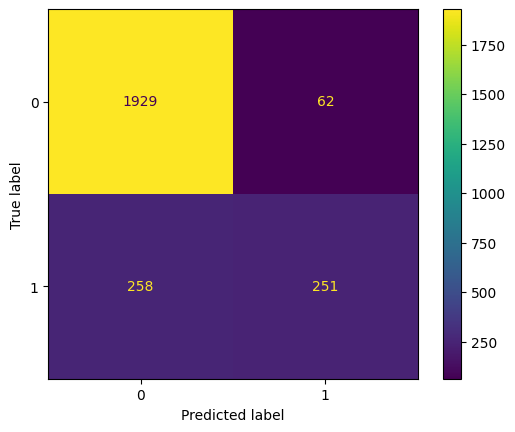

In [50]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot();

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1991
           1       0.80      0.49      0.61       509

    accuracy                           0.87      2500
   macro avg       0.84      0.73      0.77      2500
weighted avg       0.87      0.87      0.86      2500



### OOB error

In [52]:
# fit the random forest classifier with oob

clf = RandomForestClassifier(n_estimators=200, min_samples_split=10, oob_score=True)

clf.fit(X_train, y_train)

clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [53]:
clf.oob_score_

0.8604

In [54]:
oob_error = 1 - clf.oob_score_

oob_error

0.13959999999999995

### Feature Importance

- Random Forest improves accuracy by aggregatng multiple decision trees but **lose interpretability**. i.e. RF is not as interpretable as a single decision trees.

- Feature importance mitigates this problem.

#### 1. What is Feature Importance?

Feature importance tells us how much each feature (input variable) contributes to the prediction made by a model.

In the context of a Random Forest, it’s a way to rank features based on their usefulness in building decision trees that make up the forest.

#### 2. Random Forest is an ensemble of decision trees.

- Each tree is trained on a bootstrap sample (random subset) of the training data.

- At each split in a tree, a random subset of features is considered for splitting.

- The forest’s prediction is the average (for regression) or majority vote (for classification) of all trees.

Because multiple trees are built with different subsets of data and features, we can track **how often and how well** a feature is used to split data to measure its importance.

#### 3. Two Main Ways to Measure Feature Importance

**A. Mean Decrease in Impurity (MDI)**

1. Each time a feature is used to split a node, it reduces impurity in the dataset.

- For classification: impurity is usually Gini index or entropy.

- For regression: impurity is variance or MSE.

2. We sum the total impurity decrease brought by that feature over all trees and all nodes where it’s used.

3. The sum is normalized so that all feature importances add up to 1.

*mathematically:*

$$ Importance(f) = \sum_{t \in T} \sum_{n \in Nodes(t,f)} p(n) \cdot \Delta Impurity(n) / \text{Normalization Term}$$

Where:

- $p(n)$ = proportion of samples reaching node $n$

- $\Delta Impurity(n)$ = Impurty(parent) - weighted impurity (children)

- $ Nodes(t,f)$ = set of nodes in tree $t$ where feature $f$ was used

**pros:**

- Fast to compute (done during training)

- Built-in in sklearn’s RandomForestClassifier and RandomForestRegressor

**Cons:**

- Can be biased towards features with many categories or continuous features

- Doesn’t directly measure the predictive power on unseen data

In [55]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=10)

model.fit(X_train, y_train)

model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [56]:
# Get feature importances
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': output_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance
1                 Age    0.279724
10      NumOfProducts    0.167712
3             Balance    0.133298
4     EstimatedSalary    0.114682
0         CreditScore    0.111920
2              Tenure    0.063641
12     IsActiveMember    0.048161
6   Geography_Germany    0.027933
11          HasCrCard    0.012614
5    Geography_France    0.011208
8       Gender_Female    0.010442
9         Gender_Male    0.010002
7     Geography_Spain    0.008660


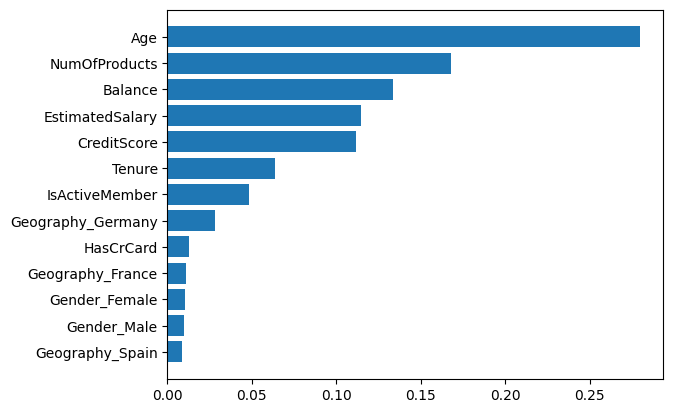

In [57]:
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.show()

**B. Mean Decrease in Accuracy (MDA) / Permutation Importance**

1. First, measure the model’s baseline accuracy (or other metric) on validation data.

2. Randomly shuffle the values of a single feature across all samples → this breaks its relationship with the target.

3. Measure the new accuracy.

4. The drop in accuracy indicates how important that feature was for prediction.

Formula:

$$ Importance(f) = Accuracy_{original} - Accuracy_{shuffled(f)} $$

**Pros:**

- Works for any model (not just tree-based)

- Measures true impact on prediction performance

**Cons:**

- Slower (requires retraining or repeated predictions)

- Can be unstable if features are correlated

In [58]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'Feature': output_features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_df)

              Feature  Importance
1                 Age    0.119013
10      NumOfProducts    0.076120
12     IsActiveMember    0.053347
3             Balance    0.048733
6   Geography_Germany    0.030027
0         CreditScore    0.024800
4     EstimatedSalary    0.024760
2              Tenure    0.021307
8       Gender_Female    0.015773
5    Geography_France    0.015627
9         Gender_Male    0.013640
11          HasCrCard    0.009880
7     Geography_Spain    0.006773


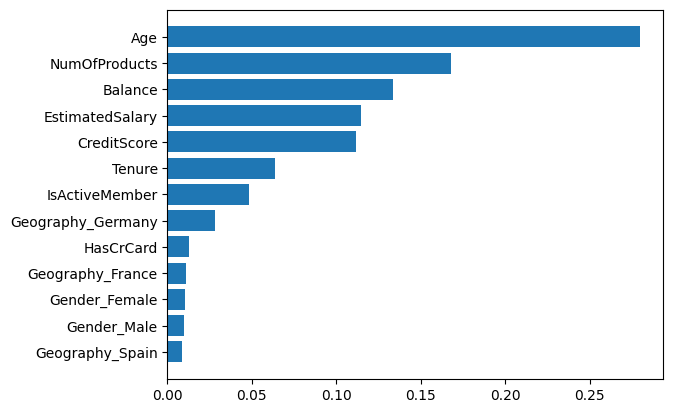

In [59]:
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.show()